In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import regionmask
from matplotlib.gridspec import GridSpec
import cartopy.crs as ccrs
import matplotlib.cm as mpl_cm

In [4]:
# === Processing functions ===
def adjust_longitude(dataset: xr.Dataset) -> xr.Dataset:
        """Swaps longitude coordinates from range (0, 360) to (-180, 180)
        Args:
            dataset (xr.Dataset): xarray Dataset
        Returns:
            xr.Dataset: xarray Dataset with swapped longitude dimensions
        """
        lon_name = "lon"  # whatever name is in the data

        # Adjust lon values to make sure they are within (-180, 180)
        dataset["_longitude_adjusted"] = xr.where(
            dataset[lon_name] > 180, dataset[lon_name] - 360, dataset[lon_name])
        dataset = (
            dataset.swap_dims({lon_name: "_longitude_adjusted"})
            .sel(**{"_longitude_adjusted": sorted(dataset._longitude_adjusted)})
            .drop_vars(lon_name)
        )

        dataset = dataset.rename({"_longitude_adjusted": lon_name})
        return dataset


# === Figure sizing ===
def autosize_figure(nrows, ncolumns, scale_factor=1, xscale_factor=1, yscale_factor=1):
    xwidth = (ncolumns+0.67) * 5.0 * scale_factor * xscale_factor
    ylength = (nrows+0.67) * 3.6 * scale_factor * yscale_factor
    return (xwidth, ylength)


# === Removing ocean ===
def land_filter(da):
    # Load in land fraction dataset
    land_110 = regionmask.defined_regions.natural_earth_v4_1_0.land_110
    da = da.where(land_110.mask_3D(da).squeeze())
    return da

In [5]:
# === Concatenate ensemble members ===
def merge_ensembles(VAR_DIR, VAR, land_mask=False):
    """ land_filter=True allows for the land filter function to remove the ocean """
    ARISE_ens = []
    SSP245_ens = []

    for ens_num in range(1, 11):
        ARISE_ens.append(xr.open_dataarray(f"{VAR_DIR}{VAR}_CESM2_ARISE_{ens_num:02d}_203501-206912.nc"))
        SSP245_ens.append(xr.open_dataarray(f"{VAR_DIR}{VAR}_CESM2_SSP245_{ens_num:02d}_202001-206912.nc"))

    arise_da = xr.concat(ARISE_ens, dim=xr.DataArray(np.arange(1, len(ARISE_ens)+1), dims="ensemble", name="ensemble"))
    ssp245_da = xr.concat(SSP245_ens, dim=xr.DataArray(np.arange(1, len(SSP245_ens)+1), dims="ensemble", name="ensemble"))

    if land_mask is True:
        print("Filtering ocean")
        arise_da = land_filter(arise_da)
        ssp245_da = land_filter(ssp245_da)

    return arise_da * 86400000, ssp245_da * 86400000  # Convert to mm/day

In [7]:
# === Path config ===
BASE_DIR = "/glade/work/awells/air_quality/CESM/PRECT_6M/"
SCENARIOS = ["ARISE", "SSP245"]


# === Main loop ===
arise_p, ssp245_p = merge_ensembles(BASE_DIR, "PRECT_6m", land_mask=True)

Filtering ocean


/glade/derecho/scratch/awells/tmp/ipykernel_38722/3054247499.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  col_map = mpl_cm.get_cmap('BrBG')


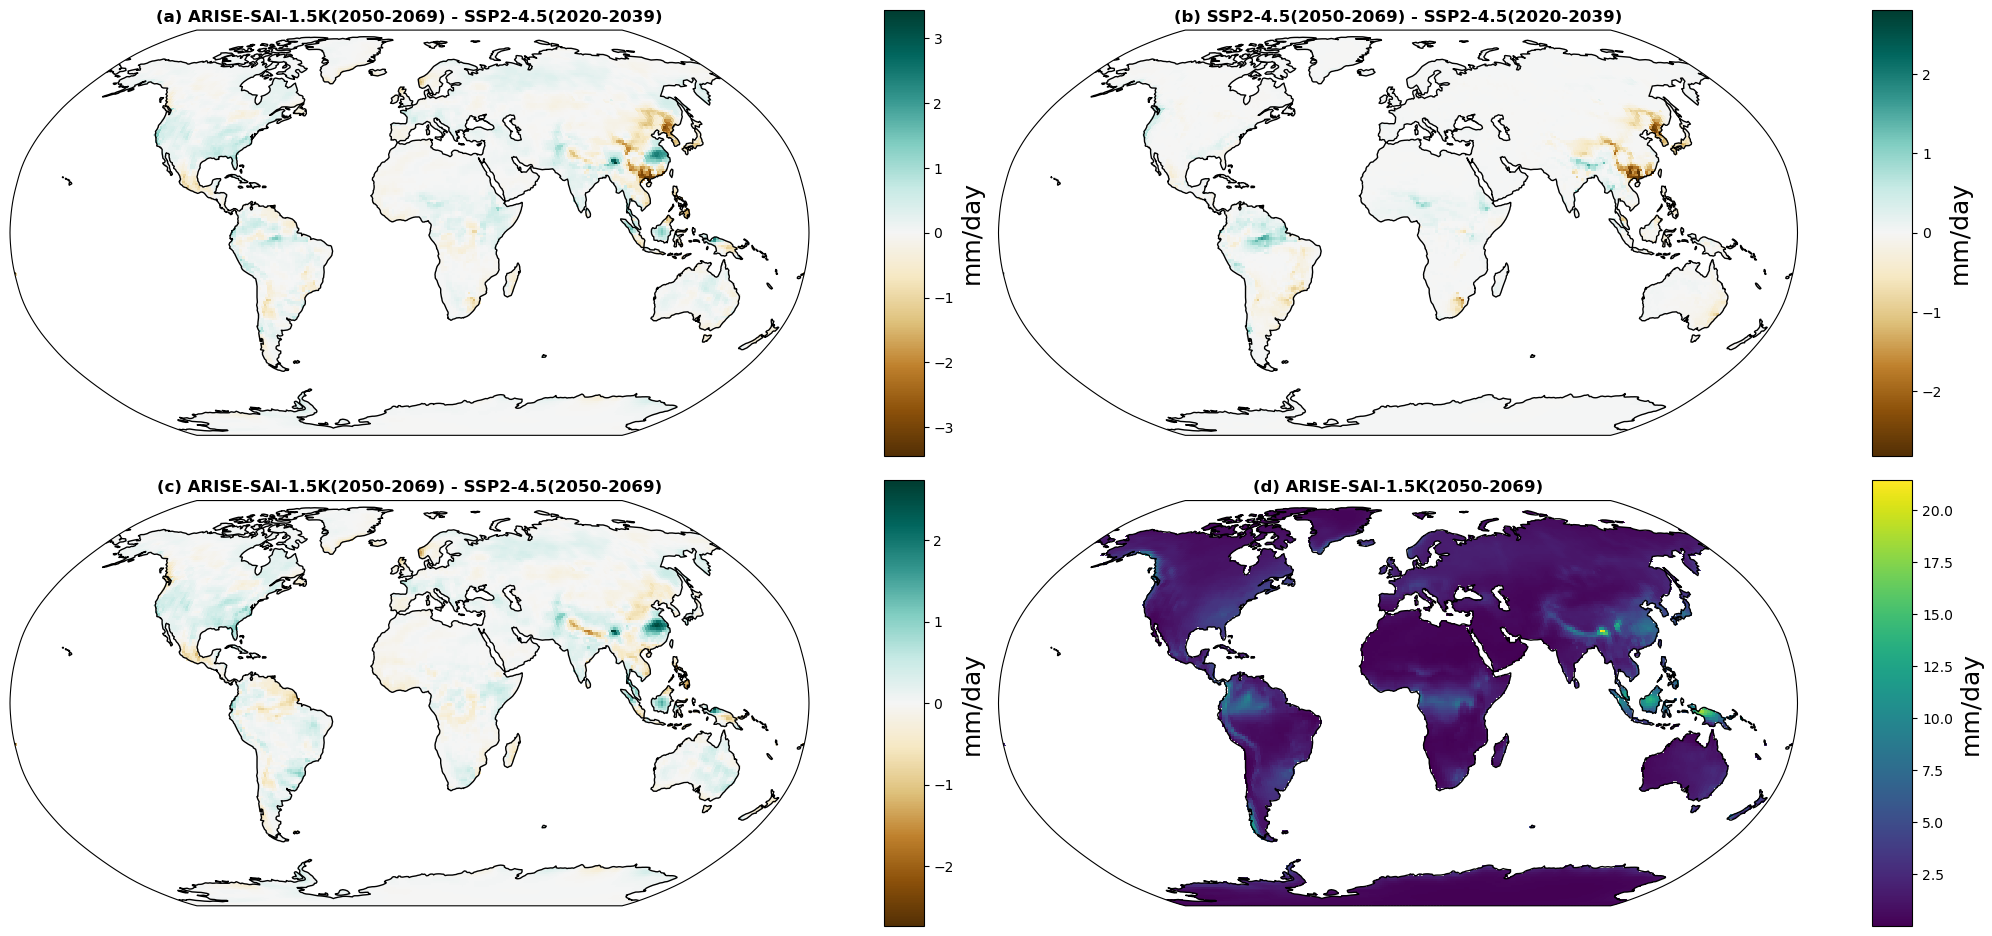

In [13]:
fig = plt.figure(figsize=autosize_figure(2, 2, xscale_factor=1.5))
gs = GridSpec(2, 4, width_ratios=[20, 1, 20, 1]) # rows, columns

projection = ccrs.Robinson()
crs = ccrs.PlateCarree()

arise = arise_p.sel(year=slice("2050", "2069")).mean(dim=("ensemble", "year"))
ssp245_early = ssp245_p.sel(year=slice("2020", "2039")).mean(dim=("ensemble", "year"))
ssp245_late = ssp245_p.sel(year=slice("2050", "2069")).mean(dim=("ensemble", "year"))

col_map = mpl_cm.get_cmap('BrBG')

# First panel
ax = fig.add_subplot(gs[0, 0], projection=projection, frameon=True)
cb = (arise - ssp245_early).plot(transform=crs, add_colorbar=False, cmap=col_map,
                         subplot_kws={'projection': projection})
ax.coastlines()
plt.title('(a) ARISE-SAI-1.5K(2050-2069) - SSP2-4.5(2020-2039)', fontweight='bold')

# First colorbar
cax = fig.add_subplot(gs[0, 1])
col_bar = plt.colorbar(cb, cax=cax, orientation='vertical')
col_bar.set_label('mm/day', fontsize=18)

# Second panel
ax = fig.add_subplot(gs[0, 2], projection=projection, frameon=True)
cb = (ssp245_late - ssp245_early).plot(transform=crs, add_colorbar=False, cmap=col_map,
                          subplot_kws={'projection': projection})
ax.coastlines()
plt.title('(b) SSP2-4.5(2050-2069) - SSP2-4.5(2020-2039)', fontweight='bold')

# Second colorbar
cax = fig.add_subplot(gs[0, 3])
col_bar = plt.colorbar(cb, cax=cax, orientation='vertical')
col_bar.set_label('mm/day', fontsize=18)

# Third panel
ax = fig.add_subplot(gs[1, 0], projection=projection, frameon=True)
cb = (arise - ssp245_late).plot(transform=crs, add_colorbar=False, cmap=col_map, 
                                    subplot_kws={'projection': projection})
ax.coastlines()
plt.title('(c) ARISE-SAI-1.5K(2050-2069) - SSP2-4.5(2050-2069)', fontweight='bold')

# Third colorbar
cax = fig.add_subplot(gs[1, 1])
col_bar = plt.colorbar(cb, cax=cax, orientation='vertical')
col_bar.set_label('mm/day', fontsize=18)

# Fourth panel
ax = fig.add_subplot(gs[1, 2], projection=projection, frameon=True)
cb = (arise).plot(transform=crs, add_colorbar=False,
                                    subplot_kws={'projection': projection})
ax.coastlines()
plt.title('(d) ARISE-SAI-1.5K(2050-2069)', fontweight='bold')

# Fourth colorbar
cax = fig.add_subplot(gs[1,3])
col_bar = plt.colorbar(cb, cax=cax, orientation='vertical')
col_bar.set_label("mm/day", fontsize=18)

plt.tight_layout()
